In [3]:
pip install tushare

  Created wheel for bs4: filename=bs4-0.0.1-py3-none-any.whl size=1273 sha256=a1b40d5a13ed1732f9ae57dabfc2e815c6bdf1cb5be9cf2185fee7ebc82db9f4
  Stored in directory: c:\users\lenove\appdata\local\pip\cache\wheels\75\78\21\68b124549c9bdc94f822c02fb9aa3578a669843f9767776bca
Successfully built bs4
Note: you may need to restart the kernel to use updated packages.


本接口即将停止更新，请尽快使用Pro版接口：https://tushare.pro/document/2
本接口即将停止更新，请尽快使用Pro版接口：https://tushare.pro/document/2


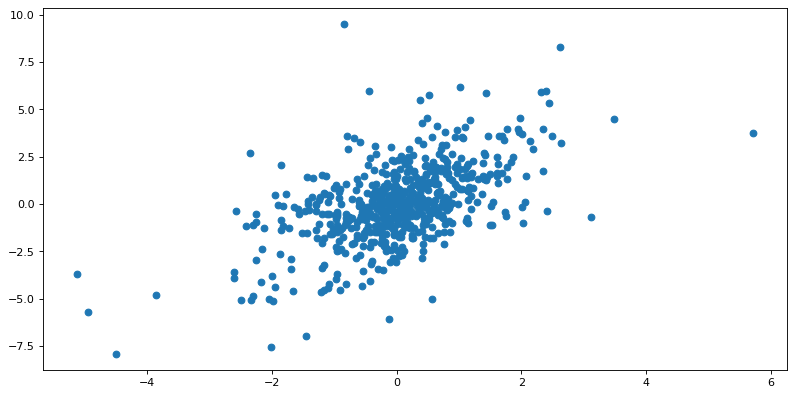


贵州茅台CAMP建立
                            OLS Regression Results                            
Dep. Variable:             p_change_y   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     269.0
Date:                Fri, 16 Dec 2022   Prob (F-statistic):           3.69e-50
Time:                        21:02:37   Log-Likelihood:                -1176.3
No. Observations:                 597   AIC:                             2357.
Df Residuals:                     595   BIC:                             2365.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0294      0.071      0.

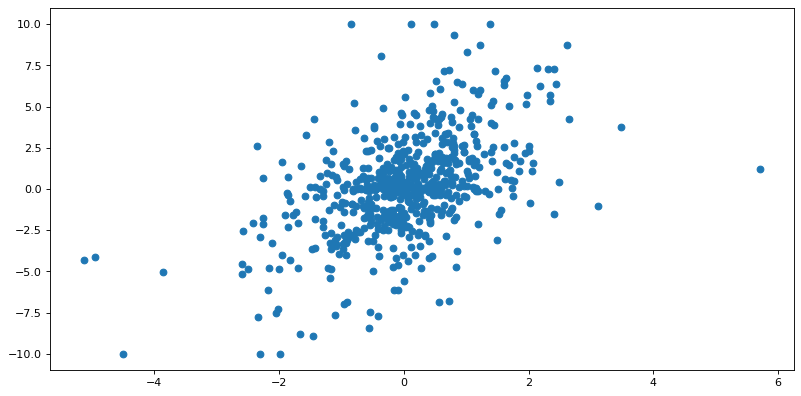


泸州老窖CAMP建立
                            OLS Regression Results                            
Dep. Variable:             p_change_y   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     203.0
Date:                Fri, 16 Dec 2022   Prob (F-statistic):           7.69e-40
Time:                        21:02:38   Log-Likelihood:                -1430.1
No. Observations:                 597   AIC:                             2864.
Df Residuals:                     595   BIC:                             2873.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1488      0.109      1.

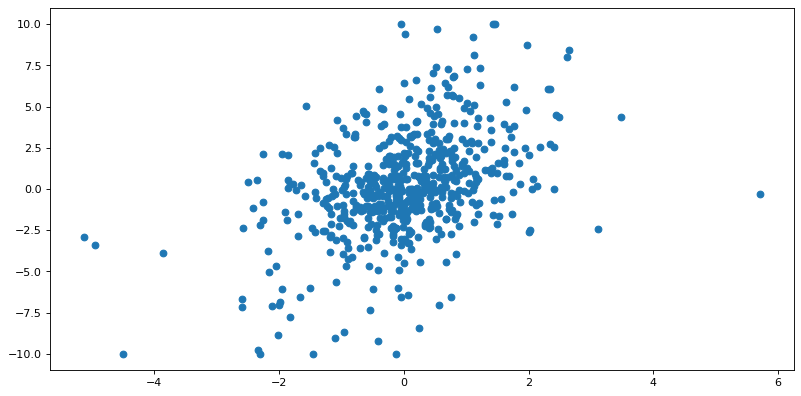


山西汾酒CAMP建立
                            OLS Regression Results                            
Dep. Variable:             p_change_y   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     130.2
Date:                Fri, 16 Dec 2022   Prob (F-statistic):           2.05e-27
Time:                        21:02:38   Log-Likelihood:                -1474.3
No. Observations:                 597   AIC:                             2953.
Df Residuals:                     595   BIC:                             2961.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1948      0.117      1.

In [2]:
'''
python3.7
-*- coding: UTF-8 -*-
@Project -> File   ：Code -> CAMP
@IDE    ：PyCharm
@Author ：YangShouWei
@USER: 296714435
@Date   ：2021/3/25 15:41:37
@LastEditor:
'''

import pandas as pd
import tushare as ts
import matplotlib.pyplot as plt
import statsmodels.api as sm


def modelCAMP(code, name):
    # 资本资产进价模型(CAPM) 
    # Ri -Rf = β*(Rm-Rf) + ε

    # 载入股指数据
    sh = ts.get_hist_data('sh', start='2019-12-01', end='2022-12-01')  # 获取上证指数数据
    stock = ts.get_hist_data(code, start='2019-12-01', end='2022-12-01')  # 获取企业三年的股票数据

    ret_merge = pd.merge(pd.DataFrame(sh.p_change), pd.DataFrame(stock.p_change), left_index=True, right_index=True, how='inner')

    # 计算日无风险利率
    Rf_year =0.04  # 以2018 年中国三年期国债年化收益率为无风险利率
    Rf = (1+Rf_year)**(1/365)-1  # 年利率转化为日利率

    # 计算风险溢价:Ri-Rf
    Eret = ret_merge-Rf
    Eret.head()

    # 画出两个风险溢价的散点图，查看相关性
    plt.figure(figsize=(12,6),dpi=80)
    plt.scatter(Eret.values[:, 0], Eret.values[:, 1])
    plt.show()

    # 利用最小二乘法进行线性回归，拟合CAPM 模型
    md_capm = sm.OLS(Eret.p_change_y[1:],sm.add_constant(Eret.p_change_x[1:]))
    result = md_capm.fit()
    result.summary()
    print("\n{}CAMP建立".format(name))
    print(result.summary())


if __name__ == "__main__":
    # 依次调用函数计算企业的CAMP拟合结果
    modelCAMP("600519", "贵州茅台")
    modelCAMP("000568", "泸州老窖")
    modelCAMP("600809", "山西汾酒")

